# Tópicos em Otimização Irrestrita

### Nome: Wesley Vitorino Teixeira
### Matrícula: 2260602

### Pacotes importados

In [40]:
#using printf
using Plots
using LinearAlgebra

### Machine epsilon

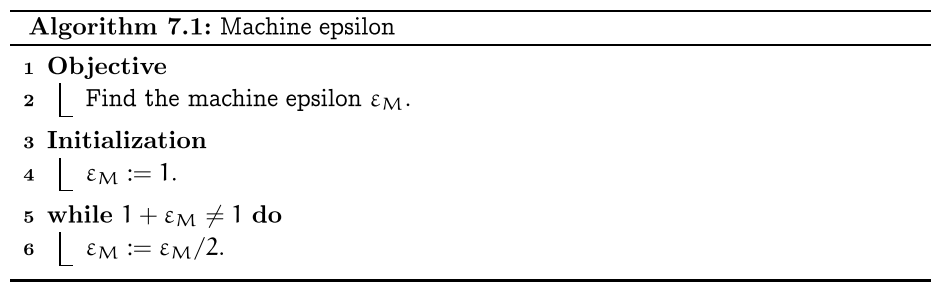

In [2]:
# Machine Epsilon
# Find the smallest ε such that 1 + ε ≠ 1 in floating-point arithmetic.
#
# Algorithm:
#   em := 1
#   while (1 + em) ≠ 1 do
#       em := em / 2
#   (the last em that still satisfied 1+em ≠ 1 is the machine epsilon)

function machine_epsilon(T::Type{<:AbstractFloat} = Float64)
    em = one(T)
    while one(T) + em != one(T)
        em /= 2
    end
    # em is now too small (1 + em == 1), so the actual epsilon is 2*em
    return em * 2
end

# ── Results for standard floating-point types ────────────────────────────────

for T in (Float16, Float32, Float64)
    em  = machine_epsilon(T)
    ref = eps(T)
    println("$T")
    println("  computed  : $em")
    println("  eps($T) : $ref")
    println("  match     : $(em == ref)")
    println()
end

Float16
  computed  : 0.000977
  eps(Float16) : 0.000977
  match     : true

Float32
  computed  : 1.1920929e-7
  eps(Float32) : 1.1920929e-7
  match     : true

Float64
  computed  : 2.220446049250313e-16
  eps(Float64) : 2.220446049250313e-16
  match     : true



In [ ]:
using Printf

em =1.0
x = 0 #cont interaction
while (em/2) + 1.0  != 1.0
    em = em/2
    x = x + 1
end

println("EPS: $em")
@printf("EPS-Decimal: %.20f\n", em)
println("Quantidade de iterações: $x" )

EPS: 2.220446049250313e-16
EPS-Decimal: 0.00000000000000022204
Quantidade de iterações: 52


### Newton's method: one variable

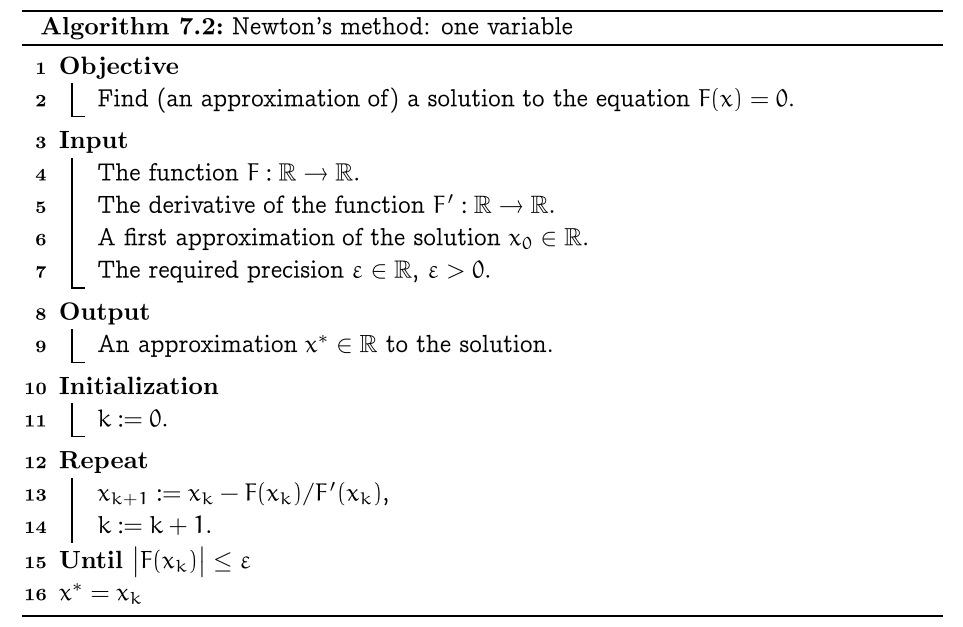

Take the equation: $F(x) = x^2 - 2 = 0$. Apply the Newton's method with $x_0 = 2, \epsilon = 10^{-15}$. Present the results such as the following:

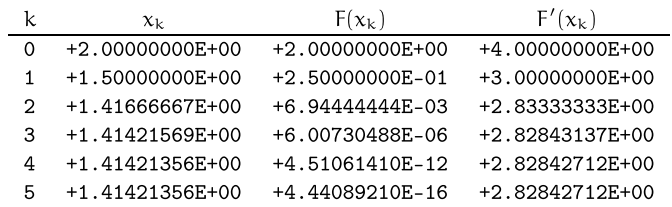

Also plot the graph with the iterations $\times$ the value of F(x).


▶  F(x) = x² - 2 = 0   |   x₀ = 2   |   ε = 1e-15
────────────────────────────────────────────────────────────────────────────────
  k      x_k                     F(x_k)                  F'(x_k)               
────────────────────────────────────────────────────────────────────────────────
  0      2.000000000000000       2.000000000000000       4.000000000000000     
  1      1.500000000000000       0.250000000000000       3.000000000000000     
  2      1.416666666666667       0.006944444444445       2.833333333333333     
  3      1.414215686274510       0.000006007304883       2.828431372549020     
  4      1.414213562374690       0.000000000004511       2.828427124749380     
  5      1.414213562373095       0.000000000000000       2.828427124746190     
────────────────────────────────────────────────────────────────────────────────

  x* = 1.414213562373095
  F(x*) = 4.440892e-16   (iterations: 5)

  √2 (reference) = 1.414213562373095
  error          = 0.000000e+00



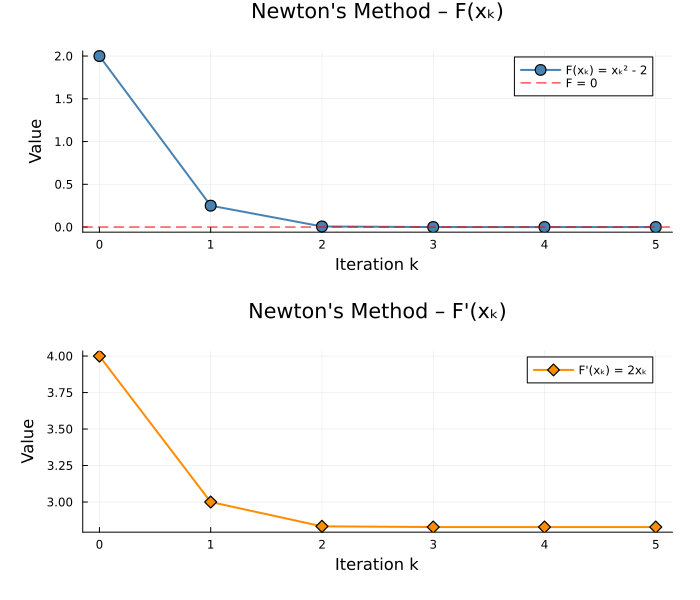

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Algorithm – Newton's Method: one variable
# Finds an approximation x* such that F(x*) ≈ 0
#
# Input:
#   F       – function ℝ → ℝ
#   dF      – derivative F′ : ℝ → ℝ
#   x0      – initial approximation
#   ε       – required precision (ε > 0)
#   maxiter – safety cap on iterations
#
# Output:
#   x*  – approximation to the solution
# ─────────────────────────────────────────────────────────────────────────────

function newton(F, dF, x0::Float64; ε::Float64 = 1e-10, maxiter::Int = 1000)
    println("─"^80)
    @printf("  %-5s  %-22s  %-22s  %-22s\n", "k", "x_k", "F(x_k)", "F'(x_k)")
    println("─"^80)

    k  = 0                          # line 11 – Initialization
    xk = x0

    # history for plotting: (k, xk, F(xk), F'(xk))
    history = Tuple{Int,Float64,Float64,Float64}[]
    push!(history, (k, xk, F(xk), dF(xk)))

    @printf("  %-5d  %-22.15f  %-22.15f  %-22.15f\n", k, xk, F(xk), dF(xk))

    while true                      # line 12 – Repeat
        dFk = dF(xk)
        if abs(dFk) < 1e-15
            error("Derivative too close to zero at x = $xk (iteration $k).")
        end

        xk1 = xk - F(xk) / dFk     # line 13 – Newton step
        k  += 1                     # line 14 – k := k + 1
        xk  = xk1

        push!(history, (k, xk, F(xk), dF(xk)))
        @printf("  %-5d  %-22.15f  %-22.15f  %-22.15f\n", k, xk, F(xk), dF(xk))

        abs(F(xk)) ≤ ε && break     # line 15 – Until |F(x_k)| ≤ ε
        k ≥ maxiter && (println("  ⚠  Maximum iterations reached."); break)
    end

    println("─"^80)
    @printf("\n  x* = %.15f\n", xk)
    @printf("  F(x*) = %.6e   (iterations: %d)\n\n", F(xk), k)

    return xk, history              # line 16 – x* = x_k
end

# ─────────────────────────────────────────────────────────────────────────────
# F(x) = x² - 2 = 0   →   x* = √2
# x₀ = 2,  ε = 1e-15
# ─────────────────────────────────────────────────────────────────────────────
println("\n▶  F(x) = x² - 2 = 0   |   x₀ = 2   |   ε = 1e-15")
x_star, hist = newton(x -> x^2 - 2.0,
                      x -> 2.0*x,
                      2.0; ε = 1e-15)

@printf("  √2 (reference) = %.15f\n", sqrt(2.0))
@printf("  error          = %.6e\n\n", abs(x_star - sqrt(2.0)))

# ─────────────────────────────────────────────────────────────────────────────
# Plot – iterations vs F(x_k) and F'(x_k)
# ─────────────────────────────────────────────────────────────────────────────
ks   = [h[1] for h in hist]
fxs  = [h[3] for h in hist]
dfxs = [h[4] for h in hist]

p1 = plot(ks, fxs;
    seriestype  = :line,
    marker      = :circle,
    markersize  = 6,
    linewidth   = 2,
    color       = :steelblue,
    label       = "F(xₖ) = xₖ² - 2",
    xlabel      = "Iteration k",
    ylabel      = "Value",
    title       = "Newton's Method – F(xₖ)",
    grid        = true,
    xticks      = ks)

hline!(p1, [0.0]; color = :red, linestyle = :dash, linewidth = 1, label = "F = 0")

p2 = plot(ks, dfxs;
    seriestype  = :line,
    marker      = :diamond,
    markersize  = 6,
    linewidth   = 2,
    color       = :darkorange,
    label       = "F'(xₖ) = 2xₖ",
    xlabel      = "Iteration k",
    ylabel      = "Value",
    title       = "Newton's Method – F'(xₖ)",
    grid        = true,
    xticks      = ks)

plot(p1, p2; layout = (2,1), size = (700, 600), margin = 5Plots.mm)


Another example: $F(x)=x-\sin(x)$. Run the example with $x_0=1$ and $\varepsilon=10^{-15}$.


▶  F(x) = x² - 2 = 0   |   x₀ = 2   |   ε = 1e-15
────────────────────────────────────────────────────────────────────────────────
  k      x_k                     F(x_k)                  F'(x_k)               
────────────────────────────────────────────────────────────────────────────────
  0      2.000000000000000       2.000000000000000       4.000000000000000     
  1      1.500000000000000       0.250000000000000       3.000000000000000     
  2      1.416666666666667       0.006944444444445       2.833333333333333     
  3      1.414215686274510       0.000006007304883       2.828431372549020     
  4      1.414213562374690       0.000000000004511       2.828427124749380     
  5      1.414213562373095       0.000000000000000       2.828427124746190     
────────────────────────────────────────────────────────────────────────────────

  x* = 1.414213562373095
  F(x*) = 4.440892e-16   (iterations: 5)

  √2 (reference) = 1.414213562373095
  error          = 0.000000e+00

▶  F(x) 

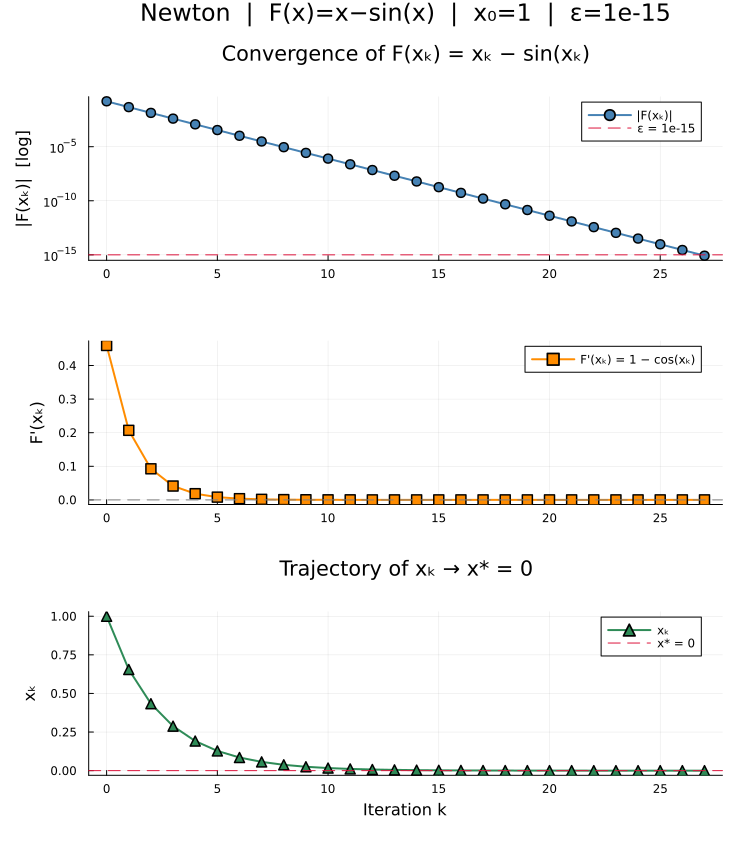

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Algorithm – Newton's Method: one variable
# Finds an approximation x* such that F(x*) ≈ 0
#
# Input:
#   F       – function ℝ → ℝ
#   dF      – derivative F′ : ℝ → ℝ
#   x0      – initial approximation
#   ε       – required precision (ε > 0)
#   maxiter – safety cap on iterations
#
# Output:
#   x*  – approximation to the solution
# ─────────────────────────────────────────────────────────────────────────────

function newton(F, dF, x0::Float64; ε::Float64 = 1e-10, maxiter::Int = 1000)
    println("─"^80)
    @printf("  %-5s  %-22s  %-22s  %-22s\n", "k", "x_k", "F(x_k)", "F'(x_k)")
    println("─"^80)

    k  = 0                          # line 11 – Initialization
    xk = x0

    # history for plotting: (k, xk, F(xk), F'(xk))
    history = Tuple{Int,Float64,Float64,Float64}[]
    push!(history, (k, xk, F(xk), dF(xk)))

    @printf("  %-5d  %-22.15f  %-22.15f  %-22.15f\n", k, xk, F(xk), dF(xk))

    while true                      # line 12 – Repeat
        dFk = dF(xk)
        if abs(dFk) < 1e-15
            error("Derivative too close to zero at x = $xk (iteration $k).")
        end

        xk1 = xk - F(xk) / dFk     # line 13 – Newton step
        k  += 1                     # line 14 – k := k + 1
        xk  = xk1

        push!(history, (k, xk, F(xk), dF(xk)))
        @printf("  %-5d  %-22.15f  %-22.15f  %-22.15f\n", k, xk, F(xk), dF(xk))

        abs(F(xk)) ≤ ε && break     # line 15 – Until |F(x_k)| ≤ ε
        k ≥ maxiter && (println("  ⚠  Maximum iterations reached."); break)
    end

    println("─"^80)
    @printf("\n  x* = %.15f\n", xk)
    @printf("  F(x*) = %.6e   (iterations: %d)\n\n", F(xk), k)

    return xk, history              # line 16 – x* = x_k
end

# ─────────────────────────────────────────────────────────────────────────────
# F(x) = x² - 2 = 0   →   x* = √2
# x₀ = 2,  ε = 1e-15
# ─────────────────────────────────────────────────────────────────────────────
println("\n▶  F(x) = x² - 2 = 0   |   x₀ = 2   |   ε = 1e-15")
x_star, hist = newton(x -> x^2 - 2.0,
                      x -> 2.0*x,
                      2.0; ε = 1e-15)

@printf("  √2 (reference) = %.15f\n", sqrt(2.0))
@printf("  error          = %.6e\n\n", abs(x_star - sqrt(2.0)))

# ─────────────────────────────────────────────────────────────────────────────
# Plot – iterations vs F(x_k) and F'(x_k)
# ─────────────────────────────────────────────────────────────────────────────
ks   = [h[1] for h in hist]
fxs  = [h[3] for h in hist]
dfxs = [h[4] for h in hist]

p1 = plot(ks, fxs;
    seriestype  = :line,
    marker      = :circle,
    markersize  = 6,
    linewidth   = 2,
    color       = :steelblue,
    label       = "F(xₖ) = xₖ² - 2",
    xlabel      = "Iteration k",
    ylabel      = "Value",
    title       = "Newton's Method – F(xₖ)",
    grid        = true,
    xticks      = ks)

hline!(p1, [0.0]; color = :red, linestyle = :dash, linewidth = 1, label = "F = 0")

p2 = plot(ks, dfxs;
    seriestype  = :line,
    marker      = :diamond,
    markersize  = 6,
    linewidth   = 2,
    color       = :darkorange,
    label       = "F'(xₖ) = 2xₖ",
    xlabel      = "Iteration k",
    ylabel      = "Value",
    title       = "Newton's Method – F'(xₖ)",
    grid        = true,
    xticks      = ks)

plot(p1, p2; layout = (2,1), size = (700, 600), margin = 5Plots.mm)

# ─────────────────────────────────────────────────────────────────────────────
# F(x) = x − sin(x) = 0   →   x* = 0
# x₀ = 1,  ε = 1e-15
# Note: F′(x) = 1 − cos(x) → 0 as x → 0, so convergence is linear (slow).
# ─────────────────────────────────────────────────────────────────────────────
println("▶  F(x) = x − sin(x) = 0   |   x₀ = 1   |   ε = 1e-15")
x_star2, hist2 = newton(x -> x - sin(x),
                        x -> 1.0 - cos(x),
                        1.0; ε = 1e-15)

@printf("  x* (reference) = 0.000000000000000\n")
@printf("  error          = %.6e\n\n", abs(x_star2 - 0.0))

# Plot – 3 panels: |F(xk)| log, F'(xk), xk trajectory
ks2   = [h[1] for h in hist2]
fxs2  = [h[3] for h in hist2]
dfxs2 = [h[4] for h in hist2]
xks2  = [h[2] for h in hist2]

p3 = plot(ks2, abs.(fxs2);
    yscale     = :log10,
    seriestype = :line, marker = :circle, markersize = 5,
    linewidth = 2, color = :steelblue,
    label = "|F(xₖ)|", ylabel = "|F(xₖ)|  [log]",
    title = "Convergence of F(xₖ) = xₖ − sin(xₖ)", grid = true)
hline!(p3, [1e-15]; color = :crimson, linestyle = :dash, label = "ε = 1e-15")

p4 = plot(ks2, dfxs2;
    seriestype = :line, marker = :square, markersize = 5,
    linewidth = 2, color = :darkorange,
    label = "F'(xₖ) = 1 − cos(xₖ)", ylabel = "F'(xₖ)", grid = true)
hline!(p4, [0.0]; color = :grey, linestyle = :dash, linewidth = 1, label = "")

p5 = plot(ks2, xks2;
    seriestype = :line, marker = :utriangle, markersize = 5,
    linewidth = 2, color = :seagreen,
    label = "xₖ", xlabel = "Iteration k", ylabel = "xₖ",
    title = "Trajectory of xₖ → x* = 0", grid = true)
hline!(p5, [0.0]; color = :crimson, linestyle = :dash, label = "x* = 0")

plot(p3, p4, p5; layout = (3,1), size = (750, 850), margin = 5Plots.mm,
            plot_title = "Newton  |  F(x)=x−sin(x)  |  x₀=1  |  ε=1e-15")


Another example: $F(x)=\arctan(x)$. Run the example with $x_0=1.5$ and $\varepsilon=10^{-15}$. We set `maxiter` to 10, as the algorithm is not converging.


▶  F(x) = x² - 2 = 0   |   x₀ = 2   |   ε = 1e-15
────────────────────────────────────────────────────────────────────────────────
  k      x_k                     F(x_k)                  F'(x_k)               
────────────────────────────────────────────────────────────────────────────────
  0      2.000000000000000       2.000000000000000       4.000000000000000     
  1      1.500000000000000       0.250000000000000       3.000000000000000     
  2      1.416666666666667       0.006944444444445       2.833333333333333     
  3      1.414215686274510       0.000006007304883       2.828431372549020     
  4      1.414213562374690       0.000000000004511       2.828427124749380     
  5      1.414213562373095       0.000000000000000       2.828427124746190     
────────────────────────────────────────────────────────────────────────────────

  ✔  Converged:  x* = 1.414213562373095
  F(xₖ) = 4.440892e-16   (iterations: 5,  status: converged)

  √2 (reference) = 1.414213562373095
  erro

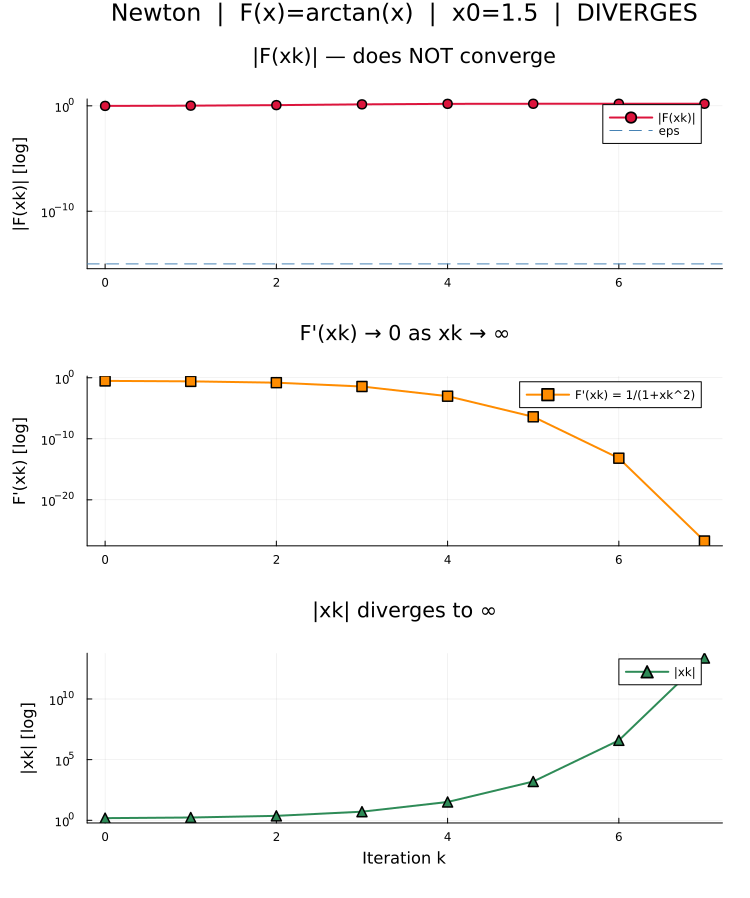

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# Algorithm – Newton's Method: one variable
# Finds an approximation x* such that F(x*) ≈ 0
#
# Input:
#   F       – function ℝ → ℝ
#   dF      – derivative F′ : ℝ → ℝ
#   x0      – initial approximation
#   ε       – required precision (ε > 0)
#   maxiter – safety cap on iterations
#
# Output:
#   x*  – approximation to the solution
# ─────────────────────────────────────────────────────────────────────────────

function newton(F, dF, x0::Float64; ε::Float64 = 1e-10, maxiter::Int = 1000)
    println("─"^80)
    @printf("  %-5s  %-22s  %-22s  %-22s\n", "k", "x_k", "F(x_k)", "F'(x_k)")
    println("─"^80)

    k  = 0                          # line 11 – Initialization
    xk = x0

    # history for plotting: (k, xk, F(xk), F'(xk))
    history = Tuple{Int,Float64,Float64,Float64}[]
    push!(history, (k, xk, F(xk), dF(xk)))

    @printf("  %-5d  %-22.15f  %-22.15f  %-22.15f\n", k, xk, F(xk), dF(xk))

    status = :running
    while true                      # line 12 – Repeat
        dFk = dF(xk)

        if abs(dFk) < 1e-15
            println("  ⚠  F\'(xₖ) ≈ 0 at k=$k — derivative vanished, stopping.")
            status = :singular
            break
        end

        xk1 = xk - F(xk) / dFk     # line 13 – Newton step
        k  += 1                     # line 14 – k := k + 1
        xk  = xk1

        if !isfinite(xk)
            println("  ⚠  xₖ diverged to Inf/NaN at k=$k — stopping.")
            status = :diverged
            break
        end

        push!(history, (k, xk, F(xk), dF(xk)))
        @printf("  %-5d  %-22.15f  %-22.15f  %-22.15f\n", k, xk, F(xk), dF(xk))

        if abs(F(xk)) ≤ ε
            status = :converged
            break                   # line 15 – Until |F(x_k)| ≤ ε
        end
        if k ≥ maxiter
            println("  ⚠  Maximum iterations ($maxiter) reached without convergence.")
            status = :maxiter
            break
        end
    end

    println("─"^80)
    if status == :converged
        @printf("\n  ✔  Converged:  x* = %.15f\n", xk)
    else
        @printf("\n  ✘  Did not converge.  Last xₖ = %.6e\n", xk)
    end
    @printf("  F(xₖ) = %.6e   (iterations: %d,  status: %s)\n\n", F(xk), k, status)

    return xk, history              # line 16 – x* = x_k
end

# ─────────────────────────────────────────────────────────────────────────────
# F(x) = x² - 2 = 0   →   x* = √2
# x₀ = 2,  ε = 1e-15
# ─────────────────────────────────────────────────────────────────────────────
println("\n▶  F(x) = x² - 2 = 0   |   x₀ = 2   |   ε = 1e-15")
x_star, hist = newton(x -> x^2 - 2.0,
                      x -> 2.0*x,
                      2.0; ε = 1e-15)

@printf("  √2 (reference) = %.15f\n", sqrt(2.0))
@printf("  error          = %.6e\n\n", abs(x_star - sqrt(2.0)))

# ─────────────────────────────────────────────────────────────────────────────
# Plot – iterations vs F(x_k) and F'(x_k)
# ─────────────────────────────────────────────────────────────────────────────
ks   = [h[1] for h in hist]
fxs  = [h[3] for h in hist]
dfxs = [h[4] for h in hist]

p1 = plot(ks, fxs;
    seriestype  = :line,
    marker      = :circle,
    markersize  = 6,
    linewidth   = 2,
    color       = :steelblue,
    label       = "F(xₖ) = xₖ² - 2",
    xlabel      = "Iteration k",
    ylabel      = "Value",
    title       = "Newton's Method – F(xₖ)",
    grid        = true,
    xticks      = ks)

hline!(p1, [0.0]; color = :red, linestyle = :dash, linewidth = 1, label = "F = 0")

p2 = plot(ks, dfxs;
    seriestype  = :line,
    marker      = :diamond,
    markersize  = 6,
    linewidth   = 2,
    color       = :darkorange,
    label       = "F'(xₖ) = 2xₖ",
    xlabel      = "Iteration k",
    ylabel      = "Value",
    title       = "Newton's Method – F'(xₖ)",
    grid        = true,
    xticks      = ks)

plot(p1, p2; layout = (2,1), size = (700, 600), margin = 5Plots.mm)


# ─────────────────────────────────────────────────────────────────────────────
# F(x) = x − sin(x) = 0   →   x* = 0
# x₀ = 1,  ε = 1e-15
# Note: F′(x) = 1 − cos(x) → 0 as x → 0, so convergence is linear (slow).
# ─────────────────────────────────────────────────────────────────────────────
println("▶  F(x) = x − sin(x) = 0   |   x₀ = 1   |   ε = 1e-15")
x_star2, hist2 = newton(x -> x - sin(x),
                        x -> 1.0 - cos(x),
                        1.0; ε = 1e-15)

@printf("  x* (reference) = 0.000000000000000\n")
@printf("  error          = %.6e\n\n", abs(x_star2 - 0.0))

# Plot – 3 panels: |F(xk)| log, F'(xk), xk trajectory
ks2   = [h[1] for h in hist2]
fxs2  = [h[3] for h in hist2]
dfxs2 = [h[4] for h in hist2]
xks2  = [h[2] for h in hist2]

p3 = plot(ks2, abs.(fxs2);
    yscale     = :log10,
    seriestype = :line, marker = :circle, markersize = 5,
    linewidth = 2, color = :steelblue,
    label = "|F(xₖ)|", ylabel = "|F(xₖ)|  [log]",
    title = "Convergence of F(xₖ) = xₖ − sin(xₖ)", grid = true)
hline!(p3, [1e-15]; color = :crimson, linestyle = :dash, label = "ε = 1e-15")

p4 = plot(ks2, dfxs2;
    seriestype = :line, marker = :square, markersize = 5,
    linewidth = 2, color = :darkorange,
    label = "F'(xₖ) = 1 − cos(xₖ)", ylabel = "F'(xₖ)", grid = true)
hline!(p4, [0.0]; color = :grey, linestyle = :dash, linewidth = 1, label = "")

p5 = plot(ks2, xks2;
    seriestype = :line, marker = :utriangle, markersize = 5,
    linewidth = 2, color = :seagreen,
    label = "xₖ", xlabel = "Iteration k", ylabel = "xₖ",
    title = "Trajectory of xₖ → x* = 0", grid = true)
hline!(p5, [0.0]; color = :crimson, linestyle = :dash, label = "x* = 0")

plot(p3, p4, p5; layout = (3,1), size = (750, 850), margin = 5Plots.mm,
            plot_title = "Newton  |  F(x)=x−sin(x)  |  x₀=1  |  ε=1e-15")

# ─────────────────────────────────────────────────────────────────────────────
# F(x) = arctan(x) = 0   →   x* = 0
# x₀ = 1.5,  ε = 1e-15,  maxiter = 10
# WARNING: does NOT converge — Newton diverges for |x₀| > 1.3917...
# ─────────────────────────────────────────────────────────────────────────────
println("▶  F(x) = arctan(x) = 0   |   x₀ = 1.5   |   ε = 1e-15   |   maxiter = 10")
_, hist3 = newton(x -> atan(x),
                  x -> 1.0 / (1.0 + x^2),
                  1.5; ε = 1e-15, maxiter = 10)

ks3   = [h[1] for h in hist3]
fxs3  = [h[3] for h in hist3]
dfxs3 = [h[4] for h in hist3]
xks3  = [h[2] for h in hist3]

p6 = plot(ks3, abs.(fxs3);
    yscale = :log10, seriestype = :line, marker = :circle, markersize = 5,
    linewidth = 2, color = :crimson, label = "|F(xk)|",
    ylabel = "|F(xk)| [log]", title = "|F(xk)| — does NOT converge", grid = true)
hline!(p6, [1e-15]; color = :steelblue, linestyle = :dash, label = "eps")

p7 = plot(ks3, abs.(dfxs3);
    yscale = :log10, seriestype = :line, marker = :square, markersize = 5,
    linewidth = 2, color = :darkorange, label = "F'(xk) = 1/(1+xk^2)",
    ylabel = "F'(xk) [log]", title = "F'(xk) → 0 as xk → ∞", grid = true)

p8 = plot(ks3, abs.(xks3);
    yscale = :log10, seriestype = :line, marker = :utriangle, markersize = 5,
    linewidth = 2, color = :seagreen, label = "|xk|",
    xlabel = "Iteration k", ylabel = "|xk| [log]",
    title = "|xk| diverges to ∞", grid = true)

plot(p6, p7, p8; layout = (3,1), size = (750, 900), margin = 5Plots.mm,
            plot_title = "Newton  |  F(x)=arctan(x)  |  x0=1.5  |  DIVERGES")


### Algorithm 7.3: Newton's method: $n$ variables

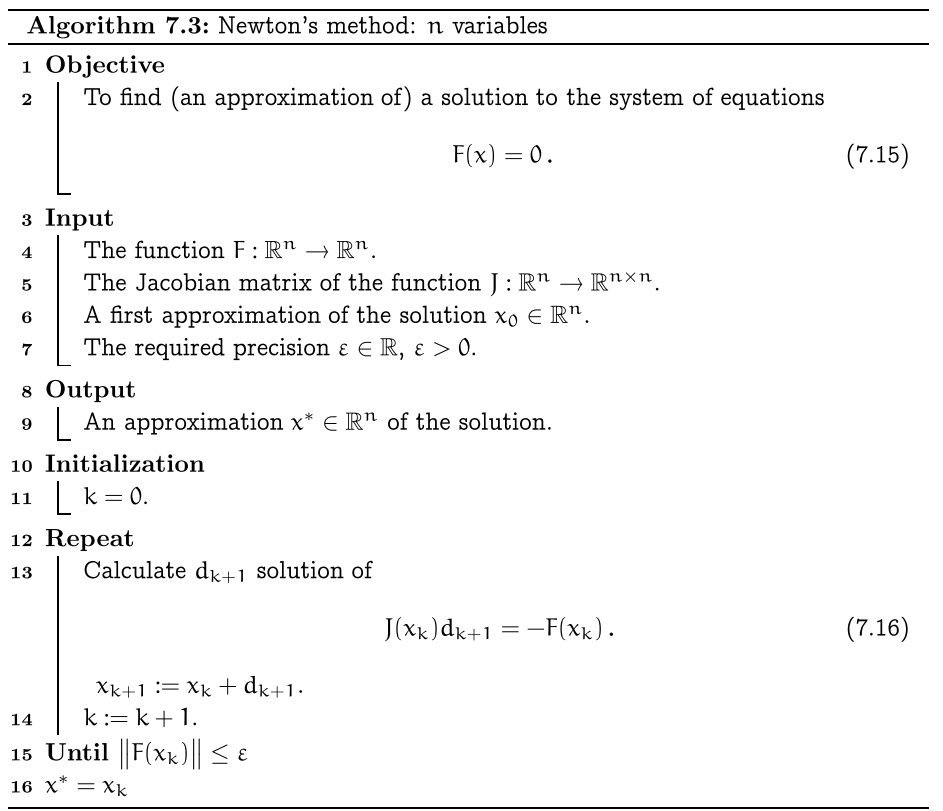

Example: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$


▶  Newton n-variables
   F(x) = [(x₁+1)² + x₂² − 2,  eˣ¹ + x₂³ − 2]ᵀ
   x₀ = (1, 1)ᵀ,   ε = 1e-15

────────────────────────────────────────────────────────────────────────────────
  k      x1_k                    x2_k                    ‖F(xₖ)‖                 det(J(xₖ))    
────────────────────────────────────────────────────────────────────────────────
  0      1.000000000000000       1.000000000000000       3.457238e+00            6.5634363431  
  1      0.152359213638757       1.195281572722486       1.154709e+00            7.0942416590  
  2      -0.010837680936146      1.036111167258880       1.140426e-01            4.3214653807  
  3      -0.000889664601470      1.001535316494101       3.942330e-03            4.0117941855  
  4      -0.000001370088751      1.000002938707905       8.079986e-06            4.0000239067  
  5      -0.000000000005538      1.000000000010795       2.883112e-11            4.0000000001  
  6      -0.000000000000000      1.000000000000000       4.440892e

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\wesle\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\wesle\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: Invalid negative or zero value 0.0 found at series index 7 for log10 based yscale
└ @ Plots C:\Users\wesle\.julia\packages\Plots\GIume\src\utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\wesle\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\wesle\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: Invalid negative or zero value 0.0 found at series index 7 for log10 based yscale
└ @ Plots C:\Users\wesle\.julia\packages\Plots\GIume\src\utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\wesle\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\wesle\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warnin

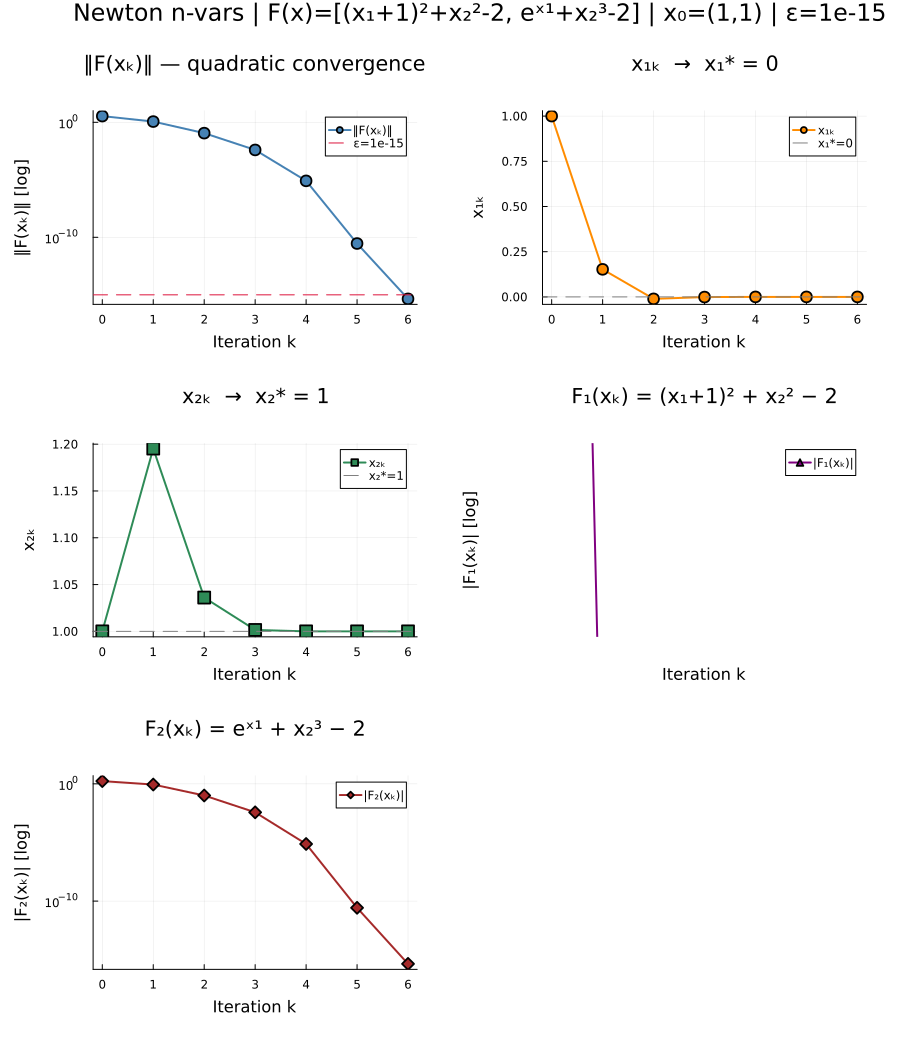

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Algorithm – Newton's Method: n variables
# Finds x* ∈ ℝⁿ such that F(x*) ≈ 0
#
# Input:
#   F       – function ℝⁿ → ℝⁿ
#   J       – Jacobian matrix J : ℝⁿ → ℝⁿˣⁿ
#   x0      – initial approximation ∈ ℝⁿ
#   ε       – required precision (ε > 0)
#   maxiter – safety cap on iterations
#
# Core step (line 13):
#   Solve  J(xₖ) · dₖ₊₁ = −F(xₖ)   for dₖ₊₁
#   Then   xₖ₊₁ := xₖ + dₖ₊₁
#
# Output:
#   x* ≈ solution,  iteration history
# ─────────────────────────────────────────────────────────────────────────────

function newton_n(F, J, x0::Vector{Float64};
                  ε::Float64 = 1e-10, maxiter::Int = 1000)

    n = length(x0)

    # header
    sep = "─"^(12 + 22*n + 24)
    println(sep)
    hdr = @sprintf("  %-5s", "k")
    for i in 1:n; hdr *= @sprintf("  %-22s", "x$(i)_k"); end
    hdr *= @sprintf("  %-22s  %-14s", "‖F(xₖ)‖", "det(J(xₖ))")
    println(hdr)
    println(sep)

    k  = 0                              # line 11 – Initialization
    xk = copy(x0)

    # history: Vector of NamedTuples
    history = NamedTuple[]
    function record(k, xk)
        push!(history, (k=k, x=copy(xk), Fx=F(xk), nrm=norm(F(xk)), detJ=det(J(xk))))
    end
    record(k, xk)

    function print_row(k, xk)
        row = @sprintf("  %-5d", k)
        for v in xk; row *= @sprintf("  %-22.15f", v); end
        row *= @sprintf("  %-22.6e  %-14.10f", norm(F(xk)), det(J(xk)))
        println(row)
    end
    print_row(k, xk)

    status = :running
    while true                          # line 12 – Repeat

        Jk = J(xk)
        Fk = F(xk)

        # Check Jacobian invertibility
        if abs(det(Jk)) < 1e-15
            println("  ⚠  Jacobian singular at k=$k — stopping.")
            status = :singular; break
        end

        dk1 = Jk \ (-Fk)               # line 13 – solve J(xk)·d = −F(xk)
        xk  = xk + dk1                  #           xₖ₊₁ := xₖ + dₖ₊₁
        k  += 1                         # line 14 – k := k + 1

        if any(!isfinite, xk)
            println("  ⚠  xₖ diverged at k=$k — stopping.")
            status = :diverged; break
        end

        record(k, xk)
        print_row(k, xk)

        if norm(F(xk)) ≤ ε              # line 15 – Until ‖F(xₖ)‖ ≤ ε
            status = :converged; break
        end
        if k ≥ maxiter
            println("  ⚠  Maximum iterations ($maxiter) reached.")
            status = :maxiter; break
        end
    end

    println(sep)
    if status == :converged
        print("\n  ✔  Converged:  x* = (")
    else
        print("\n  ✘  Did not converge.  Last x = (")
    end
    print(join([@sprintf("%.15f", v) for v in xk], ",  "))
    println(")")
    @printf("  ‖F(x*)‖ = %.6e   (iterations: %d,  status: %s)\n\n", norm(F(xk)), k, status)

    return xk, history                  # line 16 – x* = xₖ
end

# ─────────────────────────────────────────────────────────────────────────────
# Example
#
#   F(x) = [ (x₁+1)² + x₂² − 2  ]     x* = (0, 1)ᵀ
#           [ eˣ¹   + x₂³  − 2  ]
#
#   J(x) = [ 2(x₁+1)   2x₂   ]
#           [ eˣ¹       3x₂²  ]
#
#   x₀ = (1, 1)ᵀ,   ε = 1e-15
# ─────────────────────────────────────────────────────────────────────────────

F_ex = x -> [ (x[1]+1)^2 + x[2]^2 - 2.0,
               exp(x[1]) + x[2]^3   - 2.0 ]

J_ex = x -> [ 2*(x[1]+1)   2*x[2]  ;
               exp(x[1])    3*x[2]^2 ]

x0  = [1.0, 1.0]

println("\n▶  Newton n-variables")
println("   F(x) = [(x₁+1)² + x₂² − 2,  eˣ¹ + x₂³ − 2]ᵀ")
println("   x₀ = (1, 1)ᵀ,   ε = 1e-15\n")

xstar, hist = newton_n(F_ex, J_ex, x0; ε = 1e-15)

# ─────────────────────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────────────────────
ks   = [h.k   for h in hist]
x1s  = [h.x[1] for h in hist]
x2s  = [h.x[2] for h in hist]
f1s  = [abs(h.Fx[1]) for h in hist]
f2s  = [abs(h.Fx[2]) for h in hist]
nrms = [h.nrm  for h in hist]

p1 = plot(ks, nrms;
    yscale=:log10, seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:steelblue, label="‖F(xₖ)‖",
    ylabel="‖F(xₖ)‖ [log]", xlabel="Iteration k",
    title="‖F(xₖ)‖ — quadratic convergence", grid=true,
    xticks=ks)
hline!(p1, [1e-15]; color=:crimson, linestyle=:dash, label="ε=1e-15")

p2 = plot(ks, x1s;
    seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:darkorange, label="x₁ₖ",
    ylabel="x₁ₖ", xlabel="Iteration k",
    title="x₁ₖ  →  x₁* = 0", grid=true, xticks=ks)
hline!(p2, [0.0]; color=:grey, linestyle=:dash, label="x₁*=0")

p3 = plot(ks, x2s;
    seriestype=:line, marker=:square, markersize=6,
    linewidth=2, color=:seagreen, label="x₂ₖ",
    ylabel="x₂ₖ", xlabel="Iteration k",
    title="x₂ₖ  →  x₂* = 1", grid=true, xticks=ks)
hline!(p3, [1.0]; color=:grey, linestyle=:dash, label="x₂*=1")

p4 = plot(ks, f1s;
    yscale=:log10, seriestype=:line, marker=:utriangle, markersize=6,
    linewidth=2, color=:purple, label="|F₁(xₖ)|",
    ylabel="|F₁(xₖ)| [log]", xlabel="Iteration k",
    title="F₁(xₖ) = (x₁+1)² + x₂² − 2", grid=true, xticks=ks)

p5 = plot(ks, f2s;
    yscale=:log10, seriestype=:line, marker=:diamond, markersize=6,
    linewidth=2, color=:brown, label="|F₂(xₖ)|",
    ylabel="|F₂(xₖ)| [log]", xlabel="Iteration k",
    title="F₂(xₖ) = eˣ¹ + x₂³ − 2", grid=true, xticks=ks)
plot(p1, p2, p3, p4, p5;
    layout=(3,2), size=(900, 1050),
    plot_title="Newton n-vars | F(x)=[(x₁+1)²+x₂²-2, eˣ¹+x₂³-2] | x₀=(1,1) | ε=1e-15",
    margin=6Plots.mm)



Example: $F(x)=\left(\begin{array}{c}x_1^3 - 3 x_1 x_2^2 -1 \\ x_2^3 - 3x_1^2 x_2\end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$


▶  Newton n-variables — Example 2
   F(x) = [x₁³ − 3x₁x₂² − 1,  x₂³ − 3x₁²x₂]ᵀ
   x₀ = (1, 1)ᵀ,   ε = 1e-15

──────────────────────────────────────────────────────────────────────────────────
  k      x1_k                    x2_k                    ‖F(xₖ)‖                 det(J(xₖ))     
──────────────────────────────────────────────────────────────────────────────────
  0      1.000000000000000       1.000000000000000       3.605551e+00            -36.00000000   
  1      0.666666666666667       0.500000000000000       1.319964e+00            -4.34027778    
  2      0.578844444444444       -0.127466666666667      8.437363e-01            -1.11075986    
  3      1.246963981575016       0.313578425154997       1.541611e+00            -24.59913792   
  4      1.008948197751505       0.113677965154901       3.459047e-01            -9.56477743    
  5      0.987868045978376       0.003836843642865       3.771151e-02            -8.57139212    
  6      1.000134144210213       -0.000095322

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\wesle\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\wesle\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: Invalid negative or zero value 0.0 found at series index 10 for log10 based yscale
└ @ Plots C:\Users\wesle\.julia\packages\Plots\GIume\src\utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\wesle\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\wesle\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: Invalid negative or zero value 0.0 found at series index 10 for log10 based yscale
└ @ Plots C:\Users\wesle\.julia\packages\Plots\GIume\src\utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\wesle\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\wesle\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warn

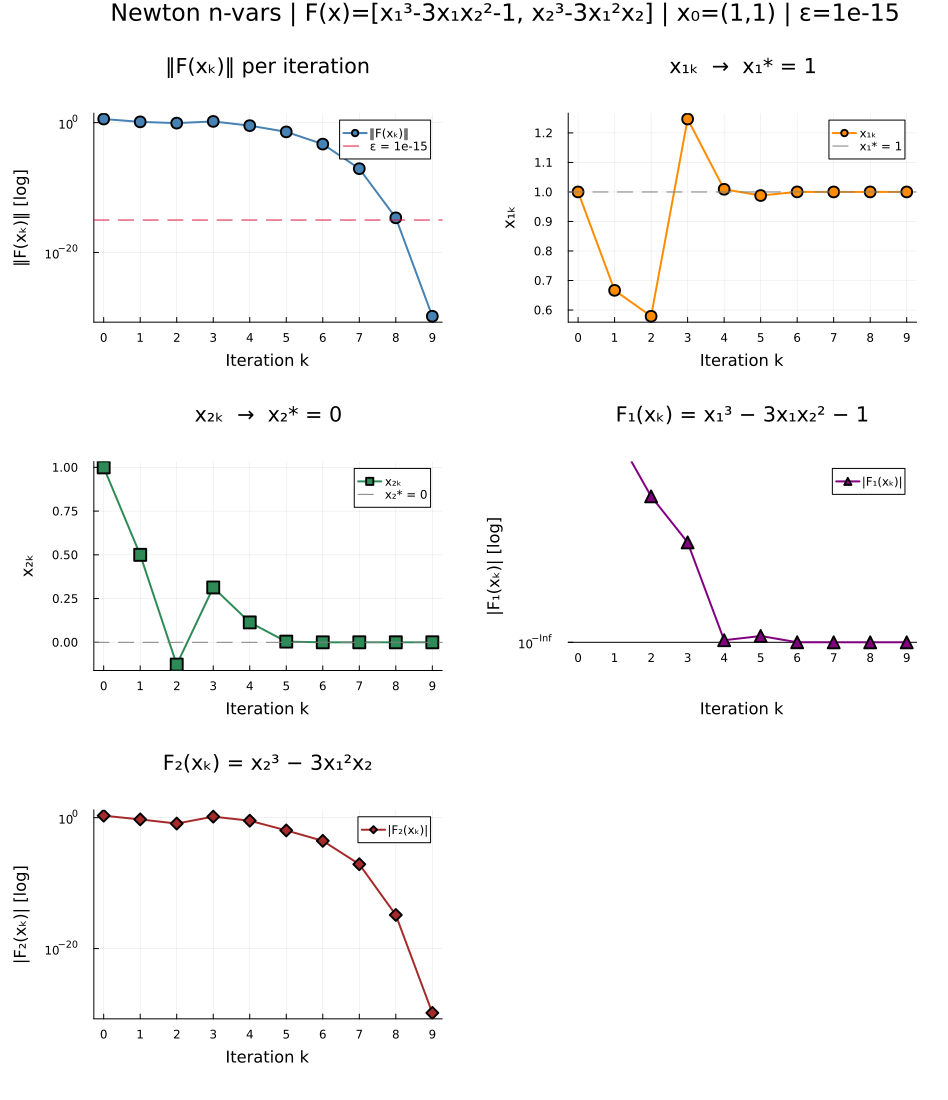

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Algorithm – Newton's Method: n variables  (reusable function)
# ─────────────────────────────────────────────────────────────────────────────

function newton_n(F, J, x0::Vector{Float64};
                  ε::Float64 = 1e-10, maxiter::Int = 1000)
    n   = length(x0)
    sep = "─" ^ (12 + 22*n + 26)

    println(sep)
    hdr = @sprintf("  %-5s", "k")
    for i in 1:n; hdr *= @sprintf("  %-22s", "x$(i)_k"); end
    hdr *= @sprintf("  %-22s  %-15s", "‖F(xₖ)‖", "det(J(xₖ))")
    println(hdr); println(sep)

    function print_row(k, xk)
        row = @sprintf("  %-5d", k)
        for v in xk; row *= @sprintf("  %-22.15f", v); end
        row *= @sprintf("  %-22.6e  %-15.8f", norm(F(xk)), det(J(xk)))
        println(row)
    end

    k  = 0                              # line 11 – Initialization
    xk = copy(x0)

    history = NamedTuple[]
    push!(history, (k=k, x=copy(xk), Fx=F(xk), nrm=norm(F(xk)), detJ=det(J(xk))))
    print_row(k, xk)

    status = :running
    while true                          # line 12 – Repeat
        Jk = J(xk); Fk = F(xk)

        if abs(det(Jk)) < 1e-14
            println("  ⚠  Jacobian near-singular at k=$k — stopping.")
            status = :singular; break
        end

        dk1 = Jk \ (-Fk)               # line 13 – solve J(xk)·d = −F(xk)
        xk  = xk + dk1                  #           xₖ₊₁ := xₖ + dₖ₊₁
        k  += 1                         # line 14 – k := k + 1

        if any(!isfinite, xk)
            println("  ⚠  xₖ diverged at k=$k — stopping.")
            status = :diverged; break
        end

        push!(history, (k=k, x=copy(xk), Fx=F(xk), nrm=norm(F(xk)), detJ=det(J(xk))))
        print_row(k, xk)

        if norm(F(xk)) ≤ ε             # line 15 – Until ‖F(xₖ)‖ ≤ ε
            status = :converged; break
        end
        if k ≥ maxiter
            println("  ⚠  Maximum iterations ($maxiter) reached.")
            status = :maxiter; break
        end
    end

    println(sep)
    sym = status == :converged ? "✔  Converged" : "✘  Did not converge"
    print("\n  $sym:  x* = (")
    print(join([@sprintf("%.15f", v) for v in xk], ",  "))
    println(")")
    @printf("  ‖F(x*)‖ = %.6e   (iterations: %d,  status: %s)\n\n",
            norm(F(xk)), k, status)

    return xk, history                  # line 16 – x* = xₖ
end

# ─────────────────────────────────────────────────────────────────────────────
# Example
#
#   F(x) = [ x₁³ − 3x₁x₂² − 1 ]     Jacobian:
#           [ x₂³ − 3x₁²x₂    ]
#
#   J(x) = [  3x₁² − 3x₂²   −6x₁x₂        ]
#           [ −6x₁x₂          3x₂² − 3x₁²  ]
#
#   x₀ = (1, 1)ᵀ,   ε = 1e-15
#
#   True root: x* = (1, 0)ᵀ
#   Verify: F₁(1,0) = 1 - 0 - 1 = 0  ✔
#           F₂(1,0) = 0 - 0     = 0  ✔
# ─────────────────────────────────────────────────────────────────────────────

F_ex = x -> [  x[1]^3 - 3*x[1]*x[2]^2 - 1.0,
               x[2]^3 - 3*x[1]^2*x[2]        ]

J_ex = x -> [  3*x[1]^2 - 3*x[2]^2    -6*x[1]*x[2]       ;
              -6*x[1]*x[2]              3*x[2]^2 - 3*x[1]^2 ]

x0 = [1.0, 1.0]

println("\n▶  Newton n-variables — Example 2")
println("   F(x) = [x₁³ − 3x₁x₂² − 1,  x₂³ − 3x₁²x₂]ᵀ")
println("   x₀ = (1, 1)ᵀ,   ε = 1e-15\n")

xstar, hist = newton_n(F_ex, J_ex, x0; ε = 1e-15)

# ─────────────────────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────────────────────
ks   = [h.k    for h in hist]
xtk  = 0:maximum(ks)
x1s  = [h.x[1] for h in hist]
x2s  = [h.x[2] for h in hist]
f1s  = [abs(h.Fx[1])         for h in hist]
f2s  = [max(abs(h.Fx[2]), 1e-35) for h in hist]
nrms = [max(h.nrm, 1e-35)    for h in hist]

p1 = plot(ks, nrms;
    yscale=:log10, seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:steelblue, label="‖F(xₖ)‖",
    ylabel="‖F(xₖ)‖ [log]", xlabel="Iteration k", xticks=xtk,
    title="‖F(xₖ)‖ per iteration", grid=true)
hline!(p1, [1e-15]; color=:crimson, linestyle=:dash, label="ε = 1e-15")

p2 = plot(ks, x1s;
    seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:darkorange, label="x₁ₖ",
    ylabel="x₁ₖ", xlabel="Iteration k", xticks=xtk,
    title="x₁ₖ  →  x₁* = 1", grid=true)
hline!(p2, [1.0]; color=:grey, linestyle=:dash, label="x₁* = 1")

p3 = plot(ks, x2s;
    seriestype=:line, marker=:square, markersize=6,
    linewidth=2, color=:seagreen, label="x₂ₖ",
    ylabel="x₂ₖ", xlabel="Iteration k", xticks=xtk,
    title="x₂ₖ  →  x₂* = 0", grid=true)
hline!(p3, [0.0]; color=:grey, linestyle=:dash, label="x₂* = 0")

p4 = plot(ks, f1s;
    yscale=:log10, seriestype=:line, marker=:utriangle, markersize=6,
    linewidth=2, color=:purple, label="|F₁(xₖ)|",
    ylabel="|F₁(xₖ)| [log]", xlabel="Iteration k", xticks=xtk,
    title="F₁(xₖ) = x₁³ − 3x₁x₂² − 1", grid=true)

p5 = plot(ks, f2s;
    yscale=:log10, seriestype=:line, marker=:diamond, markersize=6,
    linewidth=2, color=:brown, label="|F₂(xₖ)|",
    ylabel="|F₂(xₖ)| [log]", xlabel="Iteration k", xticks=xtk,
    title="F₂(xₖ) = x₂³ − 3x₁²x₂", grid=true)

plot(p1, p2, p3, p4, p5;
    layout=(3, 2), size=(950, 1100),
    plot_title="Newton n-vars | F(x)=[x₁³-3x₁x₂²-1, x₂³-3x₁²x₂] | x₀=(1,1) | ε=1e-15",
    margin=6Plots.mm)


Run the example with $x_0= \left(\begin{array}{c} -1 \\ -1 \end{array}\right)$ and $\varepsilon = 10^{-15}$


▶  Newton n-variables — Example 2
   F(x) = [x₁³ − 3x₁x₂² − 1,  x₂³ − 3x₁²x₂]ᵀ
   x₀ = (1, 1)ᵀ,   ε = 1e-15

──────────────────────────────────────────────────────────────────────────────────
  k      x1_k                    x2_k                    ‖F(xₖ)‖                 det(J(xₖ))     
──────────────────────────────────────────────────────────────────────────────────
  0      -1.000000000000000      -1.000000000000000      2.236068e+00            -36.00000000   
  1      -0.666666666666667      -0.833333333333333      5.403990e-01            -11.67361111   
  2      -0.508691916187455      -0.841099874413378      7.784043e-02            -8.40216830    
  3      -0.499329995643751      -0.866269171788006      2.138650e-03            -8.99554956    
  4      -0.499999911369913      -0.866024903156889      1.525237e-06            -8.99998280    
  5      -0.499999999999955      -0.866025403784693      7.752990e-13            -9.00000000    
  6      -0.500000000000000      -0.866025403

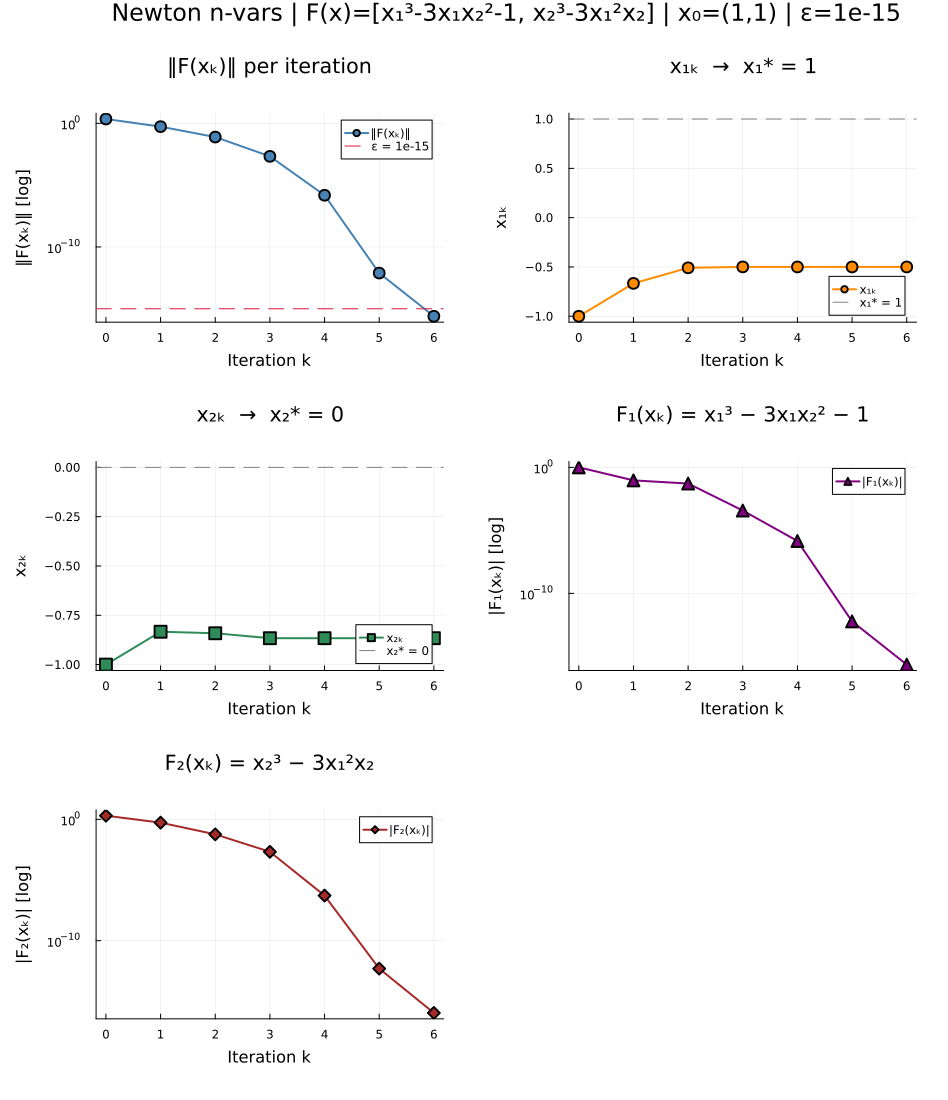

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Algorithm – Newton's Method: n variables  (reusable function)
# ─────────────────────────────────────────────────────────────────────────────

function newton_n(F, J, x0::Vector{Float64};
                  ε::Float64 = 1e-10, maxiter::Int = 1000)
    n   = length(x0)
    sep = "─" ^ (12 + 22*n + 26)

    println(sep)
    hdr = @sprintf("  %-5s", "k")
    for i in 1:n; hdr *= @sprintf("  %-22s", "x$(i)_k"); end
    hdr *= @sprintf("  %-22s  %-15s", "‖F(xₖ)‖", "det(J(xₖ))")
    println(hdr); println(sep)

    function print_row(k, xk)
        row = @sprintf("  %-5d", k)
        for v in xk; row *= @sprintf("  %-22.15f", v); end
        row *= @sprintf("  %-22.6e  %-15.8f", norm(F(xk)), det(J(xk)))
        println(row)
    end

    k  = 0                              # line 11 – Initialization
    xk = copy(x0)

    history = NamedTuple[]
    push!(history, (k=k, x=copy(xk), Fx=F(xk), nrm=norm(F(xk)), detJ=det(J(xk))))
    print_row(k, xk)

    status = :running
    while true                          # line 12 – Repeat
        Jk = J(xk); Fk = F(xk)

        if abs(det(Jk)) < 1e-14
            println("  ⚠  Jacobian near-singular at k=$k — stopping.")
            status = :singular; break
        end

        dk1 = Jk \ (-Fk)               # line 13 – solve J(xk)·d = −F(xk)
        xk  = xk + dk1                  #           xₖ₊₁ := xₖ + dₖ₊₁
        k  += 1                         # line 14 – k := k + 1

        if any(!isfinite, xk)
            println("  ⚠  xₖ diverged at k=$k — stopping.")
            status = :diverged; break
        end

        push!(history, (k=k, x=copy(xk), Fx=F(xk), nrm=norm(F(xk)), detJ=det(J(xk))))
        print_row(k, xk)

        if norm(F(xk)) ≤ ε             # line 15 – Until ‖F(xₖ)‖ ≤ ε
            status = :converged; break
        end
        if k ≥ maxiter
            println("  ⚠  Maximum iterations ($maxiter) reached.")
            status = :maxiter; break
        end
    end

    println(sep)
    sym = status == :converged ? "✔  Converged" : "✘  Did not converge"
    print("\n  $sym:  x* = (")
    print(join([@sprintf("%.15f", v) for v in xk], ",  "))
    println(")")
    @printf("  ‖F(x*)‖ = %.6e   (iterations: %d,  status: %s)\n\n",
            norm(F(xk)), k, status)

    return xk, history                  # line 16 – x* = xₖ
end

# ─────────────────────────────────────────────────────────────────────────────
# Example
#
#   F(x) = [ x₁³ − 3x₁x₂² − 1 ]     Jacobian:
#           [ x₂³ − 3x₁²x₂    ]
#
#   J(x) = [  3x₁² − 3x₂²   −6x₁x₂        ]
#           [ −6x₁x₂          3x₂² − 3x₁²  ]
#
#   x₀ = (1, 1)ᵀ,   ε = 1e-15
#
#   True root: x* = (1, 0)ᵀ
#   Verify: F₁(1,0) = 1 - 0 - 1 = 0  ✔
#           F₂(1,0) = 0 - 0     = 0  ✔
# ─────────────────────────────────────────────────────────────────────────────

F_ex = x -> [  x[1]^3 - 3*x[1]*x[2]^2 - 1.0,
               x[2]^3 - 3*x[1]^2*x[2]        ]

J_ex = x -> [  3*x[1]^2 - 3*x[2]^2    -6*x[1]*x[2]       ;
              -6*x[1]*x[2]              3*x[2]^2 - 3*x[1]^2 ]

x0 = [-1.0, -1.0] #x0 modify to -1.0 and -1.0

println("\n▶  Newton n-variables — Example 2")
println("   F(x) = [x₁³ − 3x₁x₂² − 1,  x₂³ − 3x₁²x₂]ᵀ")
println("   x₀ = (1, 1)ᵀ,   ε = 1e-15\n")

xstar, hist = newton_n(F_ex, J_ex, x0; ε = 1e-15)

# ─────────────────────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────────────────────
ks   = [h.k    for h in hist]
xtk  = 0:maximum(ks)
x1s  = [h.x[1] for h in hist]
x2s  = [h.x[2] for h in hist]
f1s  = [abs(h.Fx[1])         for h in hist]
f2s  = [max(abs(h.Fx[2]), 1e-35) for h in hist]
nrms = [max(h.nrm, 1e-35)    for h in hist]

p1 = plot(ks, nrms;
    yscale=:log10, seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:steelblue, label="‖F(xₖ)‖",
    ylabel="‖F(xₖ)‖ [log]", xlabel="Iteration k", xticks=xtk,
    title="‖F(xₖ)‖ per iteration", grid=true)
hline!(p1, [1e-15]; color=:crimson, linestyle=:dash, label="ε = 1e-15")

p2 = plot(ks, x1s;
    seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:darkorange, label="x₁ₖ",
    ylabel="x₁ₖ", xlabel="Iteration k", xticks=xtk,
    title="x₁ₖ  →  x₁* = 1", grid=true)
hline!(p2, [1.0]; color=:grey, linestyle=:dash, label="x₁* = 1")

p3 = plot(ks, x2s;
    seriestype=:line, marker=:square, markersize=6,
    linewidth=2, color=:seagreen, label="x₂ₖ",
    ylabel="x₂ₖ", xlabel="Iteration k", xticks=xtk,
    title="x₂ₖ  →  x₂* = 0", grid=true)
hline!(p3, [0.0]; color=:grey, linestyle=:dash, label="x₂* = 0")

p4 = plot(ks, f1s;
    yscale=:log10, seriestype=:line, marker=:utriangle, markersize=6,
    linewidth=2, color=:purple, label="|F₁(xₖ)|",
    ylabel="|F₁(xₖ)| [log]", xlabel="Iteration k", xticks=xtk,
    title="F₁(xₖ) = x₁³ − 3x₁x₂² − 1", grid=true)

p5 = plot(ks, f2s;
    yscale=:log10, seriestype=:line, marker=:diamond, markersize=6,
    linewidth=2, color=:brown, label="|F₂(xₖ)|",
    ylabel="|F₂(xₖ)| [log]", xlabel="Iteration k", xticks=xtk,
    title="F₂(xₖ) = x₂³ − 3x₁²x₂", grid=true)

plot(p1, p2, p3, p4, p5;
    layout=(3, 2), size=(950, 1100),
    plot_title="Newton n-vars | F(x)=[x₁³-3x₁x₂²-1, x₂³-3x₁²x₂] | x₀=(1,1) | ε=1e-15",
    margin=6Plots.mm)


Run the example with $x_0= \left(\begin{array}{c} 0 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$


▶  Newton n-variables — Example 2
   F(x) = [x₁³ − 3x₁x₂² − 1,  x₂³ − 3x₁²x₂]ᵀ
   x₀ = (1, 1)ᵀ,   ε = 1e-15

──────────────────────────────────────────────────────────────────────────────────
  k      x1_k                    x2_k                    ‖F(xₖ)‖                 det(J(xₖ))     
──────────────────────────────────────────────────────────────────────────────────
  0      0.000000000000000       1.000000000000000       1.414214e+00            -9.00000000    
  1      -0.333333333333333      0.666666666666667       5.972043e-01            -2.77777778    
  2      -0.582222222222222      0.924444444444444       3.312813e-01            -12.82170425   
  3      -0.508790803289319      0.868165511887349       2.731283e-02            -9.22785406    
  4      -0.500068739067393      0.865982218692540       2.435359e-04            -8.99989104    
  5      -0.499999996289030      0.866025398338587       1.977011e-08            -8.99999976    
  6      -0.500000000000000      0.8660254037

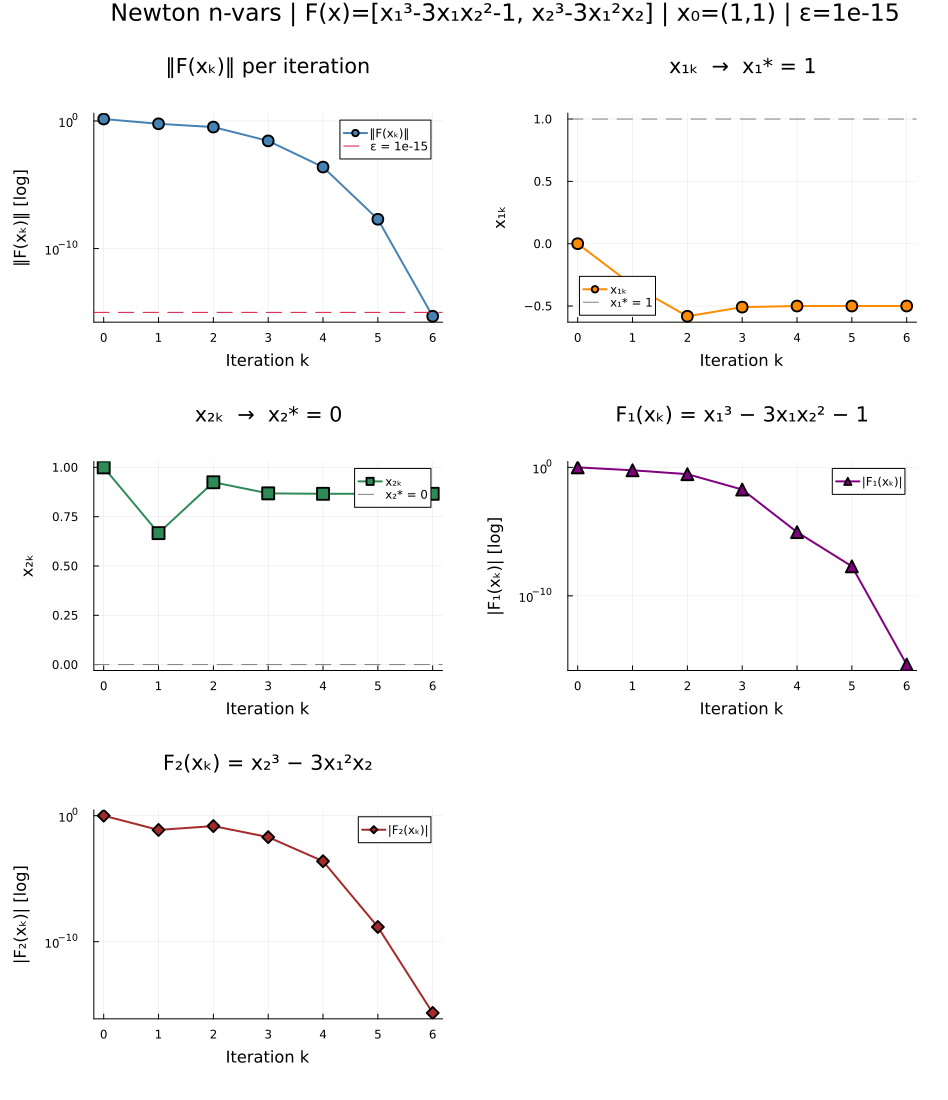

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Algorithm – Newton's Method: n variables  (reusable function)
# ─────────────────────────────────────────────────────────────────────────────

function newton_n(F, J, x0::Vector{Float64};
                  ε::Float64 = 1e-10, maxiter::Int = 1000)
    n   = length(x0)
    sep = "─" ^ (12 + 22*n + 26)

    println(sep)
    hdr = @sprintf("  %-5s", "k")
    for i in 1:n; hdr *= @sprintf("  %-22s", "x$(i)_k"); end
    hdr *= @sprintf("  %-22s  %-15s", "‖F(xₖ)‖", "det(J(xₖ))")
    println(hdr); println(sep)

    function print_row(k, xk)
        row = @sprintf("  %-5d", k)
        for v in xk; row *= @sprintf("  %-22.15f", v); end
        row *= @sprintf("  %-22.6e  %-15.8f", norm(F(xk)), det(J(xk)))
        println(row)
    end

    k  = 0                              # line 11 – Initialization
    xk = copy(x0)

    history = NamedTuple[]
    push!(history, (k=k, x=copy(xk), Fx=F(xk), nrm=norm(F(xk)), detJ=det(J(xk))))
    print_row(k, xk)

    status = :running
    while true                          # line 12 – Repeat
        Jk = J(xk); Fk = F(xk)

        if abs(det(Jk)) < 1e-14
            println("  ⚠  Jacobian near-singular at k=$k — stopping.")
            status = :singular; break
        end

        dk1 = Jk \ (-Fk)               # line 13 – solve J(xk)·d = −F(xk)
        xk  = xk + dk1                  #           xₖ₊₁ := xₖ + dₖ₊₁
        k  += 1                         # line 14 – k := k + 1

        if any(!isfinite, xk)
            println("  ⚠  xₖ diverged at k=$k — stopping.")
            status = :diverged; break
        end

        push!(history, (k=k, x=copy(xk), Fx=F(xk), nrm=norm(F(xk)), detJ=det(J(xk))))
        print_row(k, xk)

        if norm(F(xk)) ≤ ε             # line 15 – Until ‖F(xₖ)‖ ≤ ε
            status = :converged; break
        end
        if k ≥ maxiter
            println("  ⚠  Maximum iterations ($maxiter) reached.")
            status = :maxiter; break
        end
    end

    println(sep)
    sym = status == :converged ? "✔  Converged" : "✘  Did not converge"
    print("\n  $sym:  x* = (")
    print(join([@sprintf("%.15f", v) for v in xk], ",  "))
    println(")")
    @printf("  ‖F(x*)‖ = %.6e   (iterations: %d,  status: %s)\n\n",
            norm(F(xk)), k, status)

    return xk, history                  # line 16 – x* = xₖ
end

# ─────────────────────────────────────────────────────────────────────────────
# Example
#
#   F(x) = [ x₁³ − 3x₁x₂² − 1 ]     Jacobian:
#           [ x₂³ − 3x₁²x₂    ]
#
#   J(x) = [  3x₁² − 3x₂²   −6x₁x₂        ]
#           [ −6x₁x₂          3x₂² − 3x₁²  ]
#
#   x₀ = (1, 1)ᵀ,   ε = 1e-15
#
#   True root: x* = (1, 0)ᵀ
#   Verify: F₁(1,0) = 1 - 0 - 1 = 0  ✔
#           F₂(1,0) = 0 - 0     = 0  ✔
# ─────────────────────────────────────────────────────────────────────────────

F_ex = x -> [  x[1]^3 - 3*x[1]*x[2]^2 - 1.0,
               x[2]^3 - 3*x[1]^2*x[2]        ]

J_ex = x -> [  3*x[1]^2 - 3*x[2]^2    -6*x[1]*x[2]       ;
              -6*x[1]*x[2]              3*x[2]^2 - 3*x[1]^2 ]

x0 = [0.0, 1.0]

println("\n▶  Newton n-variables — Example 2")
println("   F(x) = [x₁³ − 3x₁x₂² − 1,  x₂³ − 3x₁²x₂]ᵀ")
println("   x₀ = (1, 1)ᵀ,   ε = 1e-15\n")

xstar, hist = newton_n(F_ex, J_ex, x0; ε = 1e-15)

# ─────────────────────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────────────────────
ks   = [h.k    for h in hist]
xtk  = 0:maximum(ks)
x1s  = [h.x[1] for h in hist]
x2s  = [h.x[2] for h in hist]
f1s  = [abs(h.Fx[1])         for h in hist]
f2s  = [max(abs(h.Fx[2]), 1e-35) for h in hist]
nrms = [max(h.nrm, 1e-35)    for h in hist]

p1 = plot(ks, nrms;
    yscale=:log10, seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:steelblue, label="‖F(xₖ)‖",
    ylabel="‖F(xₖ)‖ [log]", xlabel="Iteration k", xticks=xtk,
    title="‖F(xₖ)‖ per iteration", grid=true)
hline!(p1, [1e-15]; color=:crimson, linestyle=:dash, label="ε = 1e-15")

p2 = plot(ks, x1s;
    seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:darkorange, label="x₁ₖ",
    ylabel="x₁ₖ", xlabel="Iteration k", xticks=xtk,
    title="x₁ₖ  →  x₁* = 1", grid=true)
hline!(p2, [1.0]; color=:grey, linestyle=:dash, label="x₁* = 1")

p3 = plot(ks, x2s;
    seriestype=:line, marker=:square, markersize=6,
    linewidth=2, color=:seagreen, label="x₂ₖ",
    ylabel="x₂ₖ", xlabel="Iteration k", xticks=xtk,
    title="x₂ₖ  →  x₂* = 0", grid=true)
hline!(p3, [0.0]; color=:grey, linestyle=:dash, label="x₂* = 0")

p4 = plot(ks, f1s;
    yscale=:log10, seriestype=:line, marker=:utriangle, markersize=6,
    linewidth=2, color=:purple, label="|F₁(xₖ)|",
    ylabel="|F₁(xₖ)| [log]", xlabel="Iteration k", xticks=xtk,
    title="F₁(xₖ) = x₁³ − 3x₁x₂² − 1", grid=true)

p5 = plot(ks, f2s;
    yscale=:log10, seriestype=:line, marker=:diamond, markersize=6,
    linewidth=2, color=:brown, label="|F₂(xₖ)|",
    ylabel="|F₂(xₖ)| [log]", xlabel="Iteration k", xticks=xtk,
    title="F₂(xₖ) = x₂³ − 3x₁²x₂", grid=true)

plot(p1, p2, p3, p4, p5;
    layout=(3, 2), size=(950, 1100),
    plot_title="Newton n-vars | F(x)=[x₁³-3x₁x₂²-1, x₂³-3x₁²x₂] | x₀=(1,1) | ε=1e-15",
    margin=6Plots.mm)

